In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 


In [2]:

def g(t, y): 
    return y - t**2 + 1 


def f(t,y): 
    return 0.8*y *(1 - (y/10))


def fun_h(t,y):
    return np.exp(-t) - 2*y


def f_exata(t,x0):
    return 10/(1 + ((10-x0)/x0)*np.exp(-0.8*t))

def g_exata(t):
    return (t + 1)**2 - 0.5 * np.exp(t)

def h_exata(t):
    return np.exp(-t) + 2*np.exp(-2*t)

def rungeKutta(t, y, h, n,fun):
    for i in range(n):
        k1 = fun(t[i], y[i])
        k2 = fun(t[i] + h/2, y[i] + (h/2)*k1)
        k3 = fun(t[i] + h/2, y[i] + (h/2)*k2)
        k4 = fun(t[i] + h, y[i] + h*k3)
        y[i+1] = y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    return y

def euler(t, y, h, n, fun):
    for i in range(n):
        y[i+1] = y[i] + h * fun(t[i], y[i])
    return y

def heun(t, y, h, n,fun):
    for i in range(n):
        k1 = fun(t[i], y[i])
        b = y[i] + h * k1
        k2 = fun(t[i] + h, b)
        y[i+1] = y[i] + (h/2) * (k1 + k2)
    return y

def pontoMedio(t,y,h,n,fun):
    for i in range(n):
        k1 = fun(t[i], y[i])
        b = y[i] + (h/2)*k1
        k2 = fun(t[i] + h/2, b)
        y[i+1] = y[i] + h*k2

        
    return y

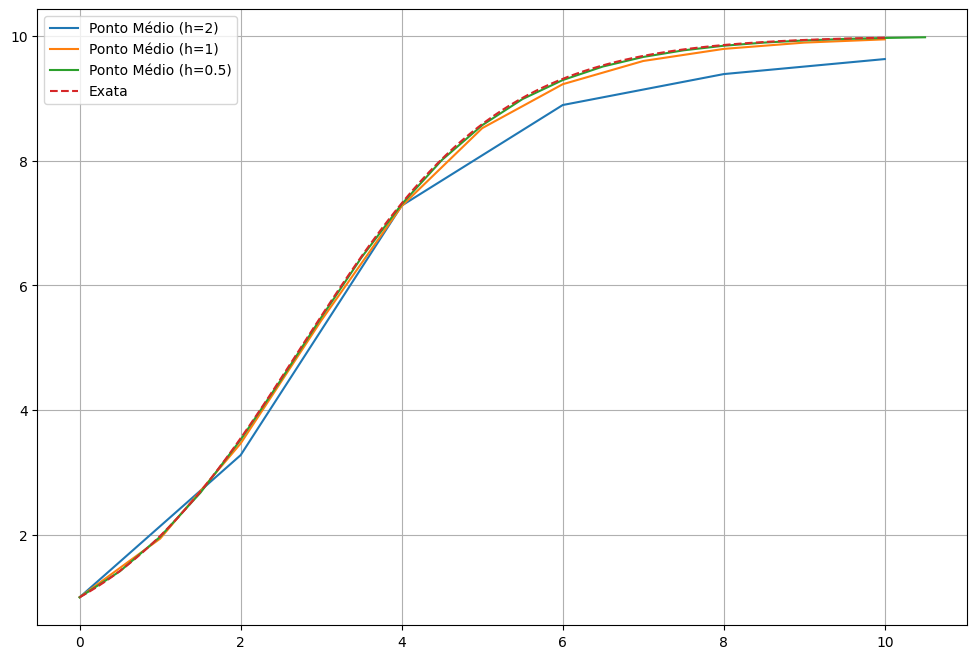

In [3]:

h_values = [2,1,0.5]
t0 = 0 
tf = 10

plt.figure(figsize=(12,8))


for hh in h_values:
    t = np.arange(t0, tf+1, hh)
    n = len(t)
    
    y = np.zeros(n)
    y2 = np.zeros(n)
    y4 = np.zeros(n)
    y[0] = 1
    y2[0] = 1
    y4[0] = 1
    

    y = heun(t, y, hh, n-1, f)
    y2 = euler(t, y2, hh, n-1, f)
    y4 = pontoMedio(t, y4, hh, n-1, f)

    t_exata = np.linspace(t0, tf, 100)
    y3 = f_exata(t_exata, 1)



    # plt.plot(t, y, label=f'Heun (h={hh})')
    # plt.plot(t, y2, label=f'Euler (h={hh})')
    plt.plot(t,y4,label = f'Ponto Médio (h={hh})')


plt.plot(t_exata, y3, label='Exata',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

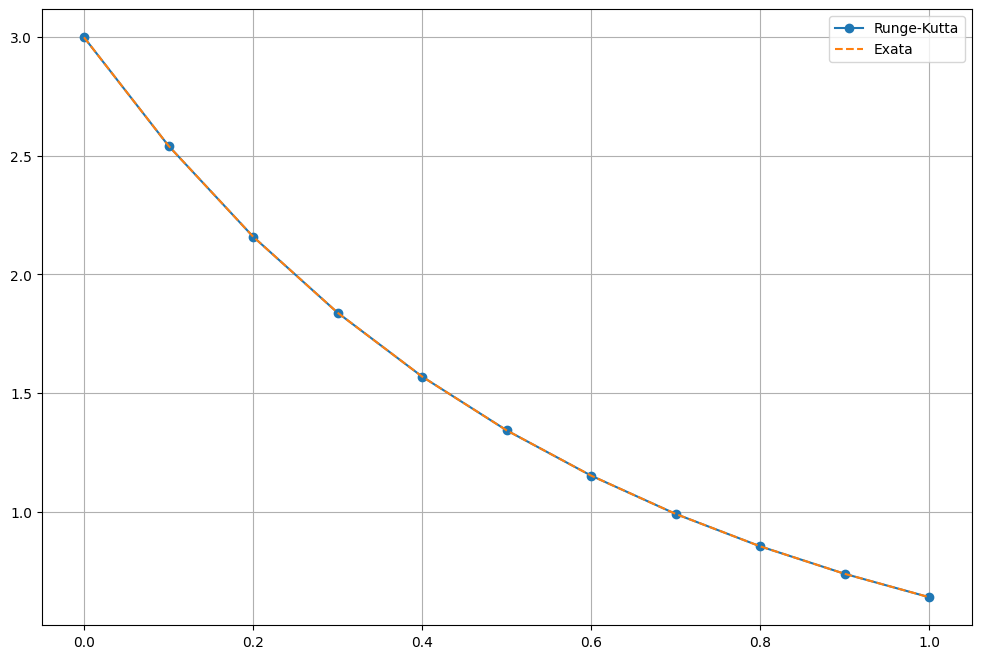

In [4]:



n = 10
y = np.zeros(n+1)
t_new = np.linspace(0, 1, n+1)
y[0] = 3 
y = rungeKutta(t_new,y,0.1,n,fun_h)
sol = h_exata(t_new) 

plt.figure(figsize=(12,8))
plt.plot(t_new,y,marker = 'o',label='Runge-Kutta')
plt.plot(t_new,sol,linestyle='--',label='Exata')
plt.grid(True)
plt.legend()
plt.show()


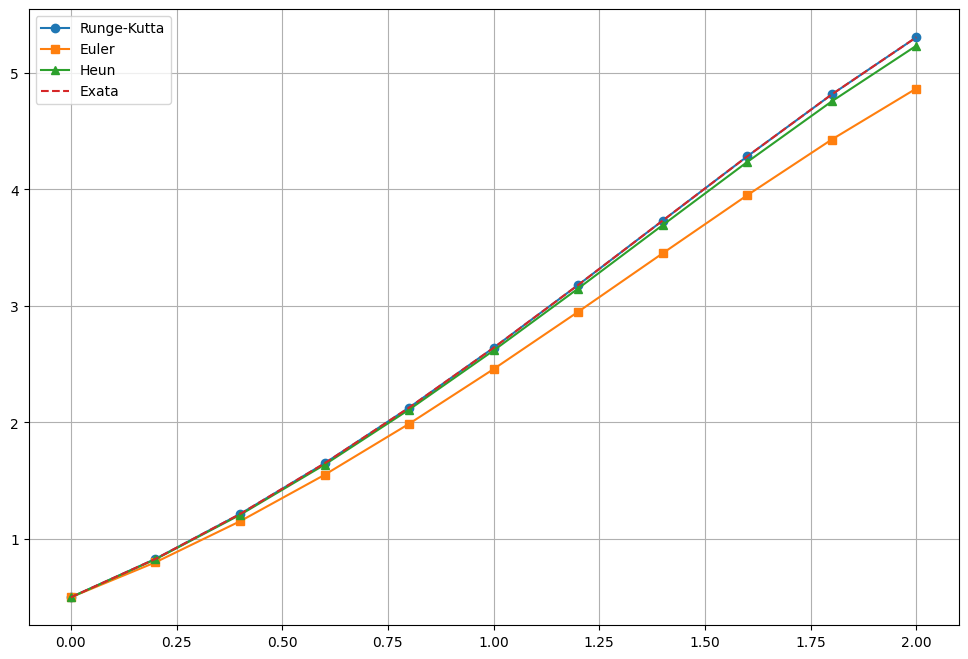

,0,1,2,3,4,5,6,7,8,9,10
Runge-Kutta,0.5,0.829293,1.214076,1.648922,2.127203,2.640823,3.179894,3.732340,4.283409,4.815086,5.305363
Euler,0.5,0.800000,1.152000,1.550400,1.988480,2.458176,2.949811,3.451773,3.950128,4.428154,4.865785
Heun,0.5,0.826000,1.206920,1.637242,2.110236,2.617688,3.149579,3.693686,4.235097,4.755619,5.233055
Exata,0.5,0.829299,1.214088,1.648941,2.127230,2.640859,3.179942,3.732400,4.283484,4.815176,5.305472


In [6]:

h2 = 0.2
t2 = np.linspace(0,2,11)

u = np.zeros(len(t2))
u[0] = 0.5
u = rungeKutta(t2,u,h2,len(t2)-1,g)

u2 = np.zeros(len(t2))
u2[0] = 0.5
u2 = euler(t2,u2,h2,len(t2)-1,g)

u3 = np.zeros(len(t2))
u3[0] = 0.5
u3 = heun(t2,u3,h2,len(t2)-1,g)




plt.figure(figsize=(12,8))
plt.plot(t2,u,marker='o', label = 'Runge-Kutta')
plt.plot(t2,u2,marker='s', label = 'Euler')
plt.plot(t2,u3,marker='^', label = 'Heun')
plt.plot(t2,g_exata(t2),linestyle='--', label = 'Exata')    # Corrigido: Passando n-1 para evitar IndexError
plt.grid(True)
plt.legend()
plt.show()


u_file = [u,u2,u3,g_exata(t2)]
pd.DataFrame(u_file, index=['Runge-Kutta', 'Euler', 'Heun','Exata'])